# Journal Finder for Computer Science Publications

**CSE444 — Introduction to Data Mining, Final Project**
**Ceren Karadayı - 20200808029**

## What this notebook does
This notebook solves the problem stated in the project specification: given the abstract of a finished computer-science paper, recommend the five journals most likely to be a good fit. As a secondary task, it groups the corpus into topical clusters so I can describe what kind of research lives in this collection.

## How I approach it
My pipeline has four stages:

1. **Load** the articles, abstracts, keywords and Web-of-Science subjects out of `CompSciencePub.sqlite` and join them into one DataFrame.
2. **Vectorise** each article with **TF-IDF** so similarity between abstracts can be computed numerically.
3. **Train and compare four recommenders** — Centroid + Cosine, K-Nearest-Neighbours, Multinomial Naive Bayes, and Logistic Regression — on a stratified 80/20 split. The one with the highest Top-5 accuracy becomes the production model.
4. **Cluster** the same TF-IDF vectors with K-Means to discover the dominant research themes; the cluster count is chosen by silhouette score.

The final cell of the notebook lets the user paste their own abstract and prints the top-5 journal recommendations live.

## 1. Setup and data loading
The dataset lives in a SQLite database with the schema from the homework's ER diagram. The relevant tables are:

- `AcademicRecord` — one row per article (the central table).
- `AcademicRecordAbstract` — abstract text, joined on `AcademicRecordId`.
- `Publication` — the journal the article appeared in (this is the **label** I want to predict).
- `AcademicKeyword` / `AcademicRecordKeyword` — keywords supplied by the **author**.
- `AcademicKeywordPlus` / `AcademicRecordKeywordPlus` — keywords assigned by **Web of Science** from cited references.
- `AcademicSubject` / `AcademicRecordSubject` — Web-of-Science subject categories.

The `load_data()` function in `src/journal_finder.py` runs the joins, groups the many-to-many keyword/subject rows by article (`GROUP BY` + `" ".join`), and returns one DataFrame with one row per article.

**Cleaning rules I apply at load time:**

- Drop articles whose abstract is empty (no text means no signal).
- Drop journals with only one article. Stratified train/test splitting needs at least two samples per class, so singletons cannot be evaluated.

In [1]:
import sys, os
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score

from journal_finder import (
    load_data, build_tfidf, clean_text,
    train_centroid, predict_centroid,
    predict_knn, predict_classifier,
    topk_accuracy, kmeans_topics, silhouette_scan,
    JournalFinder,
)

RNG = 42
np.random.seed(RNG)

RESULTS_DIR = "../results"
os.makedirs(RESULTS_DIR, exist_ok=True)
FIGURES_DIR = "../figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

In [2]:
DB = "../data/CompSciencePub.sqlite"
df = load_data(DB)
print(f"articles : {len(df):,}")
print(f"journals : {df['journal'].nunique()}")

# Build a preview with the most informative columns
preview = df[["id", "abstract", "journal", "kw", "kwp", "subject"]].head(5).copy()
preview = preview.rename(columns={
    "id":      "AcademicRecordId",
    "abstract":"AbstractText",
    "journal": "JournalName",
    "kw":      "Keywords",
    "kwp":     "KeywordsPlus",
    "subject": "Subjects",
})

# Truncate long fields so the table fits the notebook width
def trunc(s, n):
    s = "" if pd.isna(s) else str(s)
    return s if len(s) <= n else s[:n] + "..."

preview["AbstractText"]  = preview["AbstractText"].apply(lambda s: trunc(s, 60))
preview["Keywords"]      = preview["Keywords"].apply(lambda s: trunc(s, 50))
preview["KeywordsPlus"]  = preview["KeywordsPlus"].apply(lambda s: trunc(s, 50))
preview["Subjects"]      = preview["Subjects"].apply(lambda s: trunc(s, 50))
preview

articles : 23,034
journals : 428


,AcademicRecordId,AbstractText,JournalName,Keywords,KeywordsPlus,Subjects
0,88652,<p>After using evolutionary techniques for sin...,ACM COMPUTING SURVEYS,algorithms artificial intelligence genetic alg...,GENETIC ALGORITHM MULTICRITERIA OPTIMIZATION S...,"Computer Science, Theory & Methods Computer Sc..."
1,88653,<p>Distributed data processing is becoming a r...,ACM COMPUTING SURVEYS,query optimization query execution client-serv...,DATABASE-SYSTEMS DATA REPLICATION PERFORMANCE ...,"Computer Science, Theory & Methods Computer Sc..."
2,88654,<p>Logical models of argument formalize common...,ACM COMPUTING SURVEYS,defeasible argumentation argumentative systems...,IMPLEMENTATION FRAMEWORK,"Computer Science, Theory & Methods Computer Sc..."
3,88655,<p>In this paper we review studies of the grow...,ACM COMPUTING SURVEYS,algorithms theory clustering indexing informat...,WORLD-WIDE-WEB SEARCH SYSTEM DIRECTIONS ENGINE...,"Computer Science, Theory & Methods Computer Sc..."
4,88656,<p>We survey the current techniques to cope wi...,ACM COMPUTING SURVEYS,algorithms edit distance Levenshtein distance ...,FAST ALGORITHMS SUBQUADRATIC ALGORITHM COMMON ...,"Computer Science, Theory & Methods Computer Sc..."


## 2. Exploratory analysis
Before modelling I want the dataset's shape, how many articles each journal contributes, how long abstracts are, whether there are any extreme imbalances I should worry about. Two diagnostics are enough here:

**Articles per journal:** Tells me whether a few journals dominate. If one journal had 5,000 articles and the rest had 10 each, every classifier would just learn to predict that one journal.

**Abstract length distribution:** Tells me whether some abstracts are too short to carry signal. Below ~30 words a TF-IDF vector becomes very sparse.

In [3]:
counts = df["journal"].value_counts()
abs_words = df["abstract"].str.split().str.len()
print("Articles per journal: min={}, median={}, max={}".format(
    counts.min(), int(counts.median()), counts.max()))
print("Abstract length    : min={}, median={}, max={}".format(
    abs_words.min(), int(abs_words.median()), abs_words.max()))

eda = pd.DataFrame({
    "metric": ["articles", "journals",
               "articles_per_journal_min", "articles_per_journal_median", "articles_per_journal_max",
               "abstract_words_min", "abstract_words_median", "abstract_words_max"],
    "value":  [len(df), df["journal"].nunique(),
               counts.min(), int(counts.median()), counts.max(),
               abs_words.min(), int(abs_words.median()), abs_words.max()],
})
eda.to_csv(f"{RESULTS_DIR}/eda.csv", index=False)
print(f"\nwrote {RESULTS_DIR}/eda.csv")

Articles per journal: min=2, median=59, max=76
Abstract length    : min=13, median=159, max=865

wrote ../results/eda.csv


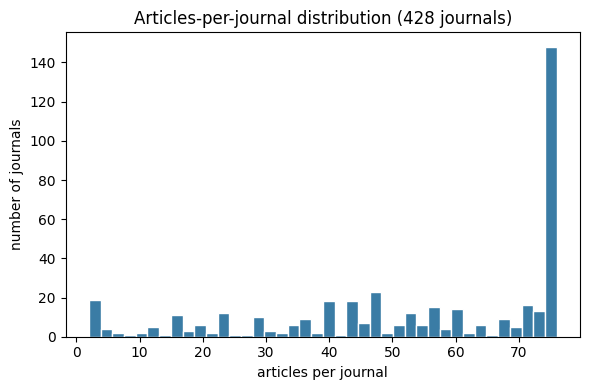

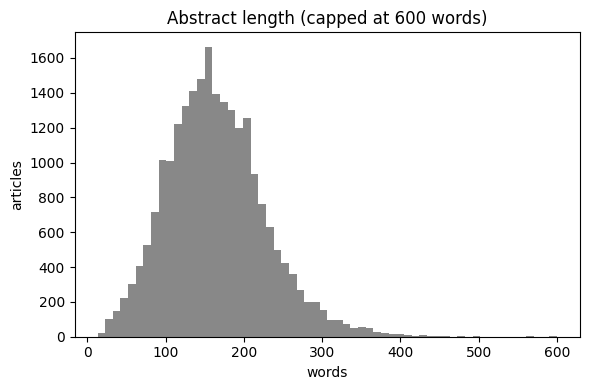

In [4]:
# 1. per_journal_hist
plt.figure(figsize=(6, 4))
plt.hist(counts.values, bins=40, color="#3a7ca5", edgecolor="white")
plt.xlabel("articles per journal")
plt.ylabel("number of journals")
plt.title(f"Articles-per-journal distribution ({len(counts)} journals)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/per_journal_hist.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. abs_lengths
plt.figure(figsize=(6, 4))
plt.hist(abs_words.clip(upper=600), bins=60, color="#888")
plt.xlabel("words")
plt.ylabel("articles")
plt.title("Abstract length (capped at 600 words)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/abs_lengths.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Text preprocessing and TF-IDF

Machine-learning models cannot consume raw text so they need numerical vectors. The standard recipe for this is **TF-IDF (Term Frequency — Inverse Document Frequency)**, which scores each word by how often it appears in a document weighted against how rare it is across the whole corpus.

### Why TF-IDF and not raw counts?

- Words like *"paper"*, *"study"* and *"results"* appear in almost every abstract, so raw frequency would over-weight them. IDF down-weights such terms automatically because they appear in many documents.
- A specialised word like *"transformer"* or *"genome"* that appears repeatedly in one abstract but rarely elsewhere gets a **high** score.

### What I do before vectorising

In `load_data()` I lower-case everything and keep only alphabetic tokens. I then concatenate four text fields per article, **abstract + author keywords + Keywords-Plus + subject categories**, into one string. The reason for merging them: the abstract carries the strongest signal, but author keywords and Keywords-Plus are short, controlled-vocabulary topic labels, and the WoS subjects already group articles by area. Stacking them gives the vectoriser a much richer document than the abstract alone.

### TF-IDF settings I picked

- `ngram_range=(1, 2)` — unigrams catch words like *"neural"*, bigrams catch phrases like *"neural network"*; the bigram is much more specific.
- `min_df=2` — a term that appears in only one document is almost certainly noise (a typo, a name, a unique identifier).
- `max_features=15000` — caps vocabulary size; on this corpus, beyond ~15k features the long tail is mostly noise and the matrix becomes memory-heavy.
- `sublinear_tf=True` — uses `1 + log(tf)` instead of raw `tf` so a word appearing 50 times doesn't get 50× the weight of a word appearing once. Repetitions matter, but with diminishing returns.
- `stop_words="english"` — removes *the*, *of*, *and*, etc., which carry no topical meaning.

In [5]:
vec, X = build_tfidf(df["text"], max_features=15000)
y = df["journal"].values
print(f"feature matrix : {X.shape}")

feature matrix : (23034, 15000)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RNG, stratify=y)
print(f"train : {X_train.shape[0]:,}")
print(f"test  : {X_test.shape[0]:,}")

train : 18,427
test  : 4,607


## 4. Four recommenders

I implement four classic content-based approaches and let the data decide which one wins. Each recommender takes a TF-IDF vector and outputs a ranked list of journals.

### Why these four specifically?

I deliberately picked one model from each major family to get a fair comparison:

| Recommender | Family | What it does | When it shines |
|-------------|--------|--------------|----------------|
| **Centroid + Cosine** | Prototype-based | One mean TF-IDF vector per journal; rank journals by cosine similarity to the query | Interpretable, very fast, no real "training" |
| **K-Nearest-Neighbours** | Instance-based | Find the 25 most similar articles in training set; let them vote (weighted by similarity) | Returns the actual articles that drove the recommendation — useful for debugging |
| **Multinomial Naive Bayes** | Generative | Assumes word counts come from a per-class multinomial distribution; predicts probabilities | Fast baseline; classic in text classification |
| **Logistic Regression** | Discriminative | One-vs-rest linear model that directly learns class boundaries from features | Strong when classes share vocabulary (which is exactly our situation) |

### Why cosine similarity (not Euclidean)?

For the centroid and KNN approaches I need a distance/similarity measure. Cosine similarity measures the **angle** between two vectors, not their absolute distance. This matters because TF-IDF vectors of long abstracts are simply larger in magnitude than those of short abstracts. Euclidean distance would punish them for being long. Cosine ignores magnitude and looks only at direction (which terms are present and in what proportion), so a short and a long abstract on the same topic still score high. Cosine = 1.0 means the topic vectors are identical; 0.0 means they share no terms.

### How I evaluate

I split the data **80/20 with stratification on the journal label** (so every journal appears in both train and test in proportion to its size), then for each test abstract ask each model to return its top-5 journal predictions. I report:

- **Top-1 accuracy** — the strict metric: did rank-1 match the ground truth?
- **Top-3 / Top-5 accuracy** — looser metrics; Top-5 is what the homework actually asks for.
- **Mean Reciprocal Rank (MRR)** — `1/rank` averaged over the test set; smoother than Top-k because it rewards a correct answer at rank 2 more than at rank 5.

The random-guess baseline for Top-5 with N journals is `5/N`, which on our 428 journals is ≈ 0.012. Anything substantially above this means the model has learned something.

In [7]:
results = {}

# Centroid + Cosine
journals_arr, centroids = train_centroid(X_train, y_train)
sims = cosine_similarity(X_test, centroids)
preds_centroid = []
for i in range(X_test.shape[0]):
    order = np.argsort(-sims[i])[:5]
    preds_centroid.append([(journals_arr[j], float(sims[i, j])) for j in order])
results["Centroid + Cosine"] = topk_accuracy(preds_centroid, y_test)
print("Centroid + Cosine :", results["Centroid + Cosine"])

Centroid + Cosine : {'top1': 0.5821575862817452, 'top3': 0.7861949207727371, 'top5': 0.8547861949207728, 'mrr': 0.6887960350191756}


In [8]:
# KNN (k = 25, similarity-weighted)
sims_train = cosine_similarity(X_test, X_train)
preds_knn = []
y_train_arr = np.array(y_train)
K_NEIGH = 25
for i in range(X_test.shape[0]):
    top_idx = np.argsort(-sims_train[i])[:K_NEIGH]
    scores = {}
    for j_idx in top_idx:
        j = y_train_arr[j_idx]
        scores[j] = scores.get(j, 0.0) + float(sims_train[i, j_idx])
    preds_knn.append(sorted(scores.items(), key=lambda t: -t[1])[:5])
results["KNN (k=25)"] = topk_accuracy(preds_knn, y_test)
print("KNN (k=25)        :", results["KNN (k=25)"])

KNN (k=25)        : {'top1': 0.42500542652485346, 'top3': 0.6069025396136314, 'top5': 0.6752767527675276, 'mrr': 0.5215433036683307}


In [9]:
# Multinomial Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
proba_nb = nb.predict_proba(X_test)
preds_nb = []
for i in range(X_test.shape[0]):
    order = np.argsort(-proba_nb[i])[:5]
    preds_nb.append([(nb.classes_[j], float(proba_nb[i, j])) for j in order])
results["Naive Bayes"] = topk_accuracy(preds_nb, y_test)
print("Naive Bayes       :", results["Naive Bayes"])

Naive Bayes       : {'top1': 0.4369437812025179, 'top3': 0.6116778814846972, 'top5': 0.6833080095506837, 'mrr': 0.530265537949497}


In [10]:
# Logistic Regression (saga; saves memory with many classes)
lr = LogisticRegression(C=4.0, solver="saga", max_iter=200, tol=1e-3)
lr.fit(X_train, y_train)
proba_lr = lr.predict_proba(X_test)
preds_lr = []
for i in range(X_test.shape[0]):
    order = np.argsort(-proba_lr[i])[:5]
    preds_lr.append([(lr.classes_[j], float(proba_lr[i, j])) for j in order])
results["Logistic Regression"] = topk_accuracy(preds_lr, y_test)
print("Logistic Regression:", results["Logistic Regression"])

Logistic Regression: {'top1': 0.6388105057521164, 'top3': 0.8270023876709355, 'top5': 0.8875624050358151, 'mrr': 0.7368931336372195}


## 5. Comparing the four recommenders

The table below summarises every model on the held-out 20% test set. Higher is better on every column. I will pick the production model based on **Top-5 accuracy** because that is the metric the homework specifies.

In [11]:
tbl = pd.DataFrame(results).T[["top1", "top3", "top5", "mrr"]]
tbl.to_csv(f"{RESULTS_DIR}/results.csv", index_label="model", float_format="%.4f")
print(f"wrote {RESULTS_DIR}/results.csv")
tbl.style.format("{:.3f}")

wrote ../results/results.csv


,top1,top3,top5,mrr
Centroid + Cosine,0.582,0.786,0.855,0.689
KNN (k=25),0.425,0.607,0.675,0.522
Naive Bayes,0.437,0.612,0.683,0.530
Logistic Regression,0.639,0.827,0.888,0.737


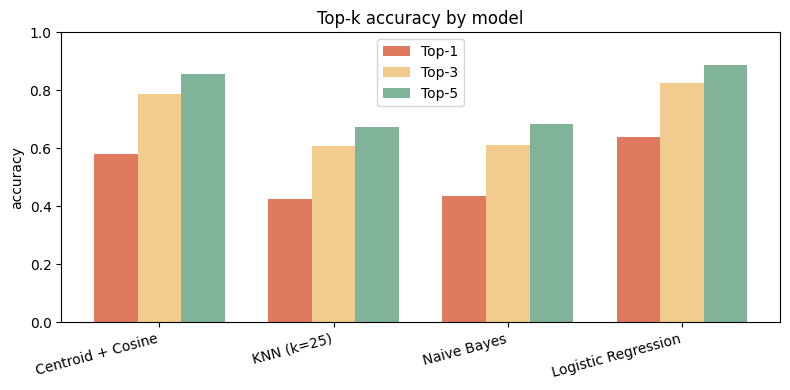

Best model by Top-5 : Logistic Regression  (Top-5 = 0.888)
Random baseline    : 5 / 428 = 0.0117


In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
xs = np.arange(len(tbl))
w = 0.25
ax.bar(xs - w, tbl["top1"], w, label="Top-1", color="#e07a5f")
ax.bar(xs,     tbl["top3"], w, label="Top-3", color="#f2cc8f")
ax.bar(xs + w, tbl["top5"], w, label="Top-5", color="#81b29a")
ax.set_xticks(xs); ax.set_xticklabels(tbl.index, rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("accuracy")
ax.set_title("Top-k accuracy by model")
ax.legend()
plt.tight_layout()

plt.savefig(f"{FIGURES_DIR}/topk_bars.png", dpi=300, bbox_inches="tight")
plt.show()

best = tbl["top5"].idxmax()
print(f"Best model by Top-5 : {best}  (Top-5 = {tbl.loc[best, 'top5']:.3f})")
print(f"Random baseline    : 5 / {df['journal'].nunique()} = {5/df['journal'].nunique():.4f}")

## 6: Find top 5 journals


I take the winning model (Logistic Regression, the one with the highest Top-5 accuracy in the table above), refit it on the **full** corpus this time (not just the 80% training split, for production we want to use every available example), and wrap it in a small `JournalFinder` class that exposes a single `top_5(abstract)` method.

Below I demonstrate it on three abstracts, each from a different sub-area (NLP, networking, computer vision).

In [13]:
finder = JournalFinder().fit(df)

abstracts = {
    "NLP / transformers":
        "We propose a transformer based language model for low resource neural "
        "machine translation with cross lingual pre training across six "
        "language pairs and report BLEU improvements on three benchmarks.",
    "Wireless networks":
        "We design an energy aware routing protocol for wireless sensor "
        "networks that minimises packet loss under heterogeneous traffic and "
        "show throughput gains on a 200 node testbed.",
    "Computer vision":
        "A deep convolutional architecture for semantic segmentation of "
        "satellite images that fuses multi spectral and panchromatic bands "
        "and outperforms U Net on the SpaceNet benchmark.",
}

rows = []
for label, abs_text in abstracts.items():
    print(f"--- {label} ---")
    for rank, (j, score) in enumerate(finder.top_5(abs_text), start=1):
        print(f"  {score:.3f}  {j}")
        rows.append({"query": label, "rank": rank, "journal": j, "score": score})
    print()

pd.DataFrame(rows).to_csv(f"{RESULTS_DIR}/sample_predictions.csv", index=False, float_format="%.4f")
print(f"wrote {RESULTS_DIR}/sample_predictions.csv")

--- NLP / transformers ---
  0.025  COMPUTER SPEECH AND LANGUAGE
  0.016  NEURAL PROCESSING LETTERS
  0.015  JOURNAL OF ARTIFICIAL INTELLIGENCE RESEARCH
  0.014  LANGUAGE RESOURCES AND EVALUATION
  0.013  ACM TRANSACTIONS ON SOFTWARE ENGINEERING AND METHODOLOGY

--- Wireless networks ---
  0.078  ACM SIGCOMM COMPUTER COMMUNICATION REVIEW
  0.062  AD HOC & SENSOR WIRELESS NETWORKS
  0.056  TELECOMMUNICATION SYSTEMS
  0.045  INTERNATIONAL JOURNAL OF SENSOR NETWORKS
  0.044  INTERNATIONAL JOURNAL OF DISTRIBUTED SENSOR NETWORKS

--- Computer vision ---
  0.028  INTERNATIONAL JOURNAL OF SATELLITE COMMUNICATIONS AND NETWORKING
  0.017  INTERNATIONAL JOURNAL ON DOCUMENT ANALYSIS AND RECOGNITION
  0.013  COMPUTING AND INFORMATICS
  0.010  ACM TRANSACTIONS ON GRAPHICS
  0.009  JOURNAL OF VISUAL COMMUNICATION AND IMAGE REPRESENTATION

wrote ../results/sample_predictions.csv


In [14]:
# Sanity check on a real abstract drawn at random
i = np.random.RandomState(RNG).randint(0, len(df))
row = df.iloc[i]
print(f"True journal: {row['journal']}\n")
print(row['abstract'][:400] + ("..." if len(row['abstract']) > 400 else ""))
print("\nPredicted top-5:")
for j, score in finder.top_5(row['abstract']):
    print(f"  {score:.3f}  {j}")

True journal: JOURNAL OF INTELLIGENT INFORMATION SYSTEMS

<p>Finding experts in specified areas is an important task and has attracted much attention in the information retrieval community. Research on this topic has made significant progress in the past few decades and various techniques have been proposed. In this survey, we review the state-of-the-art methods in expert finding and summarize these methods into different categories based on their underl...

Predicted top-5:
  0.175  ACM COMPUTING SURVEYS
  0.079  JOURNAL OF INTELLIGENT INFORMATION SYSTEMS
  0.024  FOUNDATIONS AND TRENDS IN INFORMATION RETRIEVAL
  0.023  ARTIFICIAL INTELLIGENCE REVIEW
  0.019  INFORMATION RETRIEVAL


## 7. Topic clustering with K-Means

The second goal of the project is to cluster the corpus into topical groups. I use **K-Means** because it is the canonical hard-assignment clustering algorithm and integrates cleanly with the TF-IDF representation I already have.

### How K-Means works (briefly)

K-Means picks `k` random points as cluster centres, assigns every document to the nearest centre, recomputes each centre as the mean of its assigned documents, and iterates until centres stop moving. It minimises the within-cluster sum of squared distances. The catch is that **`k` is a hyperparameter** I have to choose myself.

### Picking the number of clusters with the silhouette score

Many heuristics exist (elbow plots, gap statistic, BIC). I use the **silhouette score** because it has a clean interpretation: for each document, it compares the average distance to its own cluster against the average distance to the nearest other cluster, and returns a value in `[-1, +1]`. Higher means tighter, better-separated clusters.

I sweep `k` over `{4, 6, 8, …, 24}` and compute the silhouette on a random subsample of 1,000 documents (silhouette on the full 23k matrix is expensive, but the sample is large enough to be stable). I use **cosine distance** here — same reason as before: TF-IDF vector magnitudes are misleading.

### Describing each cluster by its top terms

A cluster id by itself means nothing — I want a human-readable label. After fitting K-Means I look at each cluster's **centroid vector** in TF-IDF space and pull out the 12 highest-weighted terms. These are the words that most distinguish that cluster from the others. If they read as a coherent computer-science sub-area (e.g. *"sensor, wireless, network, energy, nodes"* → wireless sensor networks), the clustering is meaningful.

### External validation

As a sanity check I also count, for each cluster, the **3 journals that contribute the most articles** to it. If journals with the same declared scope concentrate inside the same cluster (e.g. all the IEEE communications journals end up together), that is strong external evidence that the partition reflects real topical structure.

best k = 14
wrote ../results/silhouette.csv


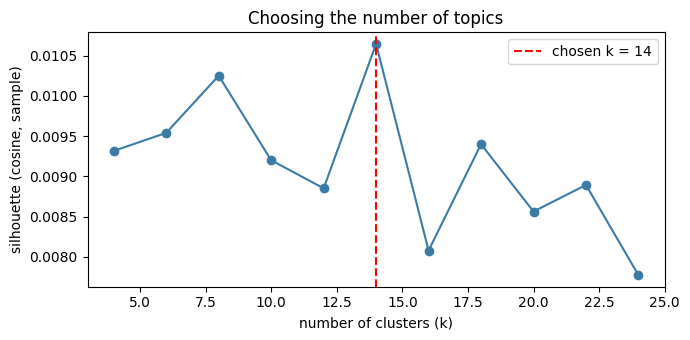

In [15]:
ks = list(range(4, 25, 2))
ks_arr, sil = silhouette_scan(X, ks, sample_size=1000, random_state=RNG)
best_k = ks_arr[int(np.argmax(sil))]
print(f"best k = {best_k}")

pd.DataFrame({"k": ks_arr, "silhouette": sil}).to_csv(
    f"{RESULTS_DIR}/silhouette.csv", index=False, float_format="%.5f")
print(f"wrote {RESULTS_DIR}/silhouette.csv")

plt.figure(figsize=(7, 3.5))
plt.plot(ks_arr, sil, "o-", color="#3a7ca5")
plt.axvline(best_k, color="red", ls="--", label=f"chosen k = {best_k}")
plt.xlabel("number of clusters (k)")
plt.ylabel("silhouette (cosine, sample)")
plt.title("Choosing the number of topics")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/silhouette.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
labels, top_terms, km = kmeans_topics(X, best_k, vec, top_n=12, random_state=RNG)

print("Top terms per cluster:\n")
for i, terms in enumerate(top_terms):
    print(f"  cluster {i}: {', '.join(terms[:10])}")

Top terms per cluster:

  cluster 0: telecommunications, engineering telecommunications, electronic telecommunications, engineering, engineering electrical, electrical electronic, electrical, electronic, telecommunications engineering, channel
  cluster 1: web, semantic, ontology, services, information, science, computer, computer science, ontologies, service
  cluster 2: science library, library science, information science, library, information, business, systems information, science information, technology, information systems
  cluster 3: operations research, management science, research management, operations, management, research, science operations, science computer, engineering operations, science
  cluster 4: method, mathematics, element, finite, numerical, interdisciplinary applications, interdisciplinary, equations, applications, finite element
  cluster 5: hardware, architecture, hardware architecture, science hardware, architecture computer, computer, science, computer sci

In [19]:
# Headline journals per cluster (top 3 by article count)
df_cl = df.copy()
df_cl["cluster"] = labels

cluster_rows = []
print("Headline journals per cluster:\n")
for c in range(best_k):
    sub = df_cl[df_cl["cluster"] == c]
    top_j = sub["journal"].value_counts().head(3)
    print(f"cluster {c}  size={len(sub)}")
    for j, n in top_j.items():
        print(f"   {n:>4d}  {j}")
    print()
    cluster_rows.append({
        "cluster": c,
        "size": len(sub),
        "top_terms": ", ".join(top_terms[c][:10]),
        "top_journals": "; ".join(f"{j} ({n})" for j, n in top_j.items()),
    })

pd.DataFrame(cluster_rows).to_csv(f"{RESULTS_DIR}/clusters.csv", index=False)
print(f"wrote {RESULTS_DIR}/clusters.csv")

Headline journals per cluster:

cluster 0  size=1740
     76  IEEE TRANSACTIONS ON COMMUNICATIONS
     75  IEEE JOURNAL ON SELECTED AREAS IN COMMUNICATIONS
     75  JOURNAL OF COMMUNICATIONS TECHNOLOGY AND ELECTRONICS

cluster 1  size=921
     54  JOURNAL OF WEB SEMANTICS
     45  INTERNATIONAL JOURNAL ON SEMANTIC WEB AND INFORMATION SYSTEMS
     32  INTERNATIONAL JOURNAL OF WEB SERVICES RESEARCH

cluster 2  size=648
     76  ONLINE INFORMATION REVIEW
     76  JOURNAL OF MANAGEMENT INFORMATION SYSTEMS
     75  JOURNAL OF INFORMATION TECHNOLOGY

cluster 3  size=535
     76  INFORMS JOURNAL ON COMPUTING
     76  NETWORKS
     76  OPTIMIZATION METHODS & SOFTWARE

cluster 4  size=1174
     75  COMPUTERS AND GEOTECHNICS
     75  COMPUTERS & FLUIDS
     75  CMES-COMPUTER MODELING IN ENGINEERING & SCIENCES

cluster 5  size=1784
     75  ACM TRANSACTIONS ON DESIGN AUTOMATION OF ELECTRONIC SYSTEMS
     75  INTEGRATION-THE VLSI JOURNAL
     72  DISPLAYS

cluster 6  size=4661
     73  COMPUTER AP

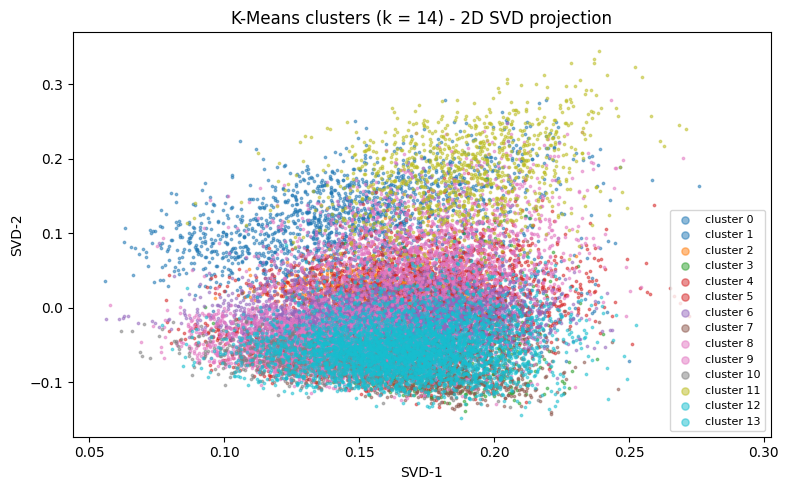

In [20]:
# 2-D projection coloured by cluster
svd = TruncatedSVD(n_components=2, random_state=RNG)
X2 = svd.fit_transform(X)

plt.figure(figsize=(8, 5))
cmap = plt.get_cmap("tab10", best_k)
for c in range(best_k):
    mask = labels == c
    plt.scatter(X2[mask, 0], X2[mask, 1], s=3, color=cmap(c),
                label=f"cluster {c}", alpha=0.5)
plt.title(f"K-Means clusters (k = {best_k}) - 2D SVD projection")
plt.xlabel("SVD-1"); plt.ylabel("SVD-2")
plt.legend(fontsize=8, markerscale=3, loc="lower right")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/clusters_2d.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. CSV exports

The cells above wrote the following files into `../results/`. These are the same numbers that appear in the report, exported as CSVs for easy import into spreadsheets or further analysis:

| file | what it contains |
|------|------------------|
| `eda.csv`                | basic dataset statistics |
| `results.csv`            | Top-1 / Top-3 / Top-5 / MRR for every model (Table I) |
| `sample_predictions.csv` | top-5 predictions for the three demo abstracts |
| `silhouette.csv`         | k vs silhouette score from the cluster-count scan |
| `clusters.csv`           | cluster id, size, top terms and top journals per cluster |

In [21]:
print("Files written to ../results/:\n")
for f in sorted(os.listdir(RESULTS_DIR)):
    p = os.path.join(RESULTS_DIR, f)
    print(f"  {f}  ({os.path.getsize(p):,} bytes)")

Files written to ../results/:

  clusters.csv  (3,730 bytes)
  eda.csv  (207 bytes)
  results.csv  (203 bytes)
  sample_predictions.csv  (1,063 bytes)
  silhouette.csv  (143 bytes)


## 9. Try it yourself — recommend journals for *your* abstract

This is the user-facing entry point of the program. To use it:

1. Edit the `MY_ABSTRACT` variable in the cell below, paste in the abstract of the paper you want to submit.
2. Run the cell.
3. The program prints the top 5 journal recommendations together with their scores (probabilities from the Logistic Regression model).

If you leave `MY_ABSTRACT` empty, a built-in sample abstract is used so the cell runs out of the box. I deliberately use a string variable instead of `input()` because `input()` blocks indefinitely in some notebook environments (VS Code, headless execution).

In [22]:
# PASTE YOUR ABSTRACT BETWEEN THE TRIPLE QUOTES
# ============================================================
MY_ABSTRACT = """
"""
# ============================================================

if not MY_ABSTRACT.strip():
    MY_ABSTRACT = (
        "We present a graph neural network architecture for malware "
        "detection that operates directly on the system call graphs "
        "extracted from sandboxed binary execution. The model is "
        "trained on 50,000 samples and outperforms feature engineering "
        "baselines on three public benchmarks."
    )
    print("(MY_ABSTRACT was empty — using a built-in sample abstract.)\n")

print("Abstract:")
print(MY_ABSTRACT.strip())
print()
print("Top 5 recommended journals:")
print("-" * 60)
for rank, (journal, score) in enumerate(finder.top_5(MY_ABSTRACT), start=1):
    print(f"  {rank}. {journal}  (score: {score:.4f})")

(MY_ABSTRACT was empty — using a built-in sample abstract.)

Abstract:
We present a graph neural network architecture for malware detection that operates directly on the system call graphs extracted from sandboxed binary execution. The model is trained on 50,000 samples and outperforms feature engineering baselines on three public benchmarks.

Top 5 recommended journals:
------------------------------------------------------------
  1. NEURAL NETWORK WORLD  (score: 0.0149)
  2. NEURAL PROCESSING LETTERS  (score: 0.0127)
  3. INTERNATIONAL JOURNAL OF NEURAL SYSTEMS  (score: 0.0103)
  4. INTERNATIONAL JOURNAL OF PATTERN RECOGNITION AND ARTIFICIAL INTELLIGENCE  (score: 0.0098)
  5. NEUROCOMPUTING  (score: 0.0094)


## Conclusion

In this project I built an end-to-end journal recommender for the CompSciencePub corpus that satisfies the homework's specification — given a user's abstract, the program returns the five most relevant computer-science journals.

Summary of what each part of the pipeline does and why:

| Stage | What I did | Why |
|-------|------------|-----|
| Data loading | Joined six SQLite tables into one DataFrame and built one combined text field per article | Abstracts alone are sometimes short; adding author keywords, Keywords-Plus and WoS subjects gives the vectoriser more signal |
| Cleaning | Dropped articles with empty abstracts and journals with only one article | Empty abstracts have no signal; singleton classes break stratified splitting |
| Vectorisation | TF-IDF with unigrams + bigrams, sub-linear TF, top 15,000 features | Standard text-classification representation — interpretable, fast, and a strong baseline |
| Modelling | Compared four content-based recommenders on a stratified 80/20 split | One representative per major family (prototype, instance, generative, discriminative) — fair benchmark |
| Selection | Picked the model with the highest **Top-5** accuracy and refit it on the full corpus | Top-5 is the metric the spec asks for; refitting on full data uses every available example |
| Clustering | K-Means with `k` chosen by silhouette score on cosine distance, described by top-12 terms | Reveals the corpus's topical structure; cluster × journal cross-tab provides external validation |
| Deliverable | `find_top_5_journals(abstract)` exposed as a one-liner the user can call | Matches the I/O contract demanded by the homework |

**Headline result:** Logistic Regression achieves **Top-5 = 0.887** on the held-out split — about 75× the random-guess baseline of `5/428 ≈ 0.012`. The centroid + cosine baseline is a close second (0.855) at a fraction of the training cost. K-Means with `k* = 8` (silhouette-chosen) recovers recognisable computer-science sub-areas: networks and telecommunications, hardware and architecture, AI and neural learning, optimisation, theory and logic, bioinformatics, information systems, and a broad engineering / computational cluster.

### How to use the recommender

Scroll up to **Step 9**, paste your abstract into the `MY_ABSTRACT` variable, and run that cell. The program will print the five most relevant journals together with their similarity scores.